# Morphological Operations Experiments

**Goal**: Noise removal dengan edge preservation  
**Operations**: Opening, Closing, Combined  
**Depends on**: Notebook 2 contrast-enhanced images

---

## Setup & Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, Tuple, List
import pandas as pd

plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

## Load Sample Images & Apply Contrast Enhancement

In [2]:
DATASET_PATH = Path('../../datasets/test')
image_files = list(DATASET_PATH.glob('*.jpg'))[:10]

print(f"Loaded {len(image_files)} sample images")
print("Will apply contrast enhancement before morphology...")

Loaded 10 sample images
Will apply contrast enhancement before morphology...


## Load Optimal Contrast Enhancement (dari Notebook 2)

In [3]:
def apply_clahe(image: np.ndarray, clip_limit: float = 3.0, tile_size: Tuple[int, int] = (8, 8)) -> np.ndarray:
    """Apply CLAHE - optimal technique dari Notebook 2"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(gray)

def calculate_edge_density(image: np.ndarray) -> float:
    """Calculate edge density untuk validation"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    edges = cv2.Canny(gray, 50, 150)
    return np.sum(edges > 0) / edges.size

print("Contrast enhancement function loaded")

Contrast enhancement function loaded


## Morphological Operations Implementation

In [4]:
def apply_opening(image: np.ndarray, kernel_size: int = 3) -> np.ndarray:
    """Apply opening operation (erosion → dilation)"""
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    opened = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
    return opened

def apply_closing(image: np.ndarray, kernel_size: int = 3) -> np.ndarray:
    """Apply closing operation (dilation → erosion)"""
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    closed = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
    return closed

def apply_combined_morphology(image: np.ndarray, 
                              opening_kernel: int = 3, 
                              closing_kernel: int = 3) -> np.ndarray:
    """Apply opening then closing"""
    opened = apply_opening(image, opening_kernel)
    closed = apply_closing(opened, closing_kernel)
    return closed

def calculate_noise_metric(image: np.ndarray) -> float:
    """Estimate noise level using local variance"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    # Calculate local variance as noise indicator
    mean = cv2.GaussianBlur(gray, (5, 5), 0)
    variance = np.mean((gray.astype(float) - mean.astype(float)) ** 2)
    return variance

print("Morphological operations defined")

Morphological operations defined


## Test Configurations

In [5]:
# Test different kernel sizes and operations
test_configs = [
    {'operation': 'none', 'params': {}},
    {'operation': 'opening', 'params': {'kernel_size': 3}},
    {'operation': 'opening', 'params': {'kernel_size': 5}},
    {'operation': 'opening', 'params': {'kernel_size': 7}},
    {'operation': 'closing', 'params': {'kernel_size': 3}},
    {'operation': 'closing', 'params': {'kernel_size': 5}},
    {'operation': 'closing', 'params': {'kernel_size': 7}},
    {'operation': 'combined', 'params': {'opening_kernel': 3, 'closing_kernel': 3}},
    {'operation': 'combined', 'params': {'opening_kernel': 5, 'closing_kernel': 5}},
    {'operation': 'combined', 'params': {'opening_kernel': 3, 'closing_kernel': 5}},
]

print(f"Testing {len(test_configs)} morphological configurations")

Testing 10 morphological configurations


## Apply Morphology & Measure Performance

In [6]:
# Test all configurations
results = []

for img_path in image_files:
    # Load and enhance contrast first
    original = cv2.imread(str(img_path))
    contrast_enhanced = apply_clahe(original)
    
    # Baseline metrics (after contrast enhancement)
    baseline_edges = calculate_edge_density(contrast_enhanced)
    baseline_noise = calculate_noise_metric(contrast_enhanced)
    
    for config in test_configs:
        operation = config['operation']
        params = config['params']
        
        # Apply morphology
        if operation == 'none':
            processed = contrast_enhanced
            param_str = "none"
        elif operation == 'opening':
            processed = apply_opening(contrast_enhanced, **params)
            param_str = f"kernel={params['kernel_size']}"
        elif operation == 'closing':
            processed = apply_closing(contrast_enhanced, **params)
            param_str = f"kernel={params['kernel_size']}"
        elif operation == 'combined':
            processed = apply_combined_morphology(contrast_enhanced, **params)
            param_str = f"open={params['opening_kernel']}, close={params['closing_kernel']}"
        
        # Calculate metrics
        processed_edges = calculate_edge_density(processed)
        processed_noise = calculate_noise_metric(processed)
        
        # Edge preservation ratio
        edge_preservation = (processed_edges / baseline_edges) if baseline_edges > 0 else 0
        
        # Noise reduction
        noise_reduction = ((baseline_noise - processed_noise) / baseline_noise * 100) if baseline_noise > 0 else 0
        
        results.append({
            'filename': img_path.name,
            'operation': operation,
            'parameters': param_str,
            'baseline_edges': baseline_edges,
            'processed_edges': processed_edges,
            'edge_preservation': edge_preservation,
            'baseline_noise': baseline_noise,
            'processed_noise': processed_noise,
            'noise_reduction_pct': noise_reduction
        })

df = pd.DataFrame(results)
print(f"Processed {len(image_files)} images with {len(test_configs)} operations")
print(f"Total test cases: {len(df)}")

Processed 10 images with 10 operations
Total test cases: 100


## Results Analysis

In [7]:
# Aggregate results by operation
summary = df.groupby(['operation', 'parameters']).agg({
    'edge_preservation': 'mean',
    'noise_reduction_pct': 'mean',
    'processed_edges': 'mean'
}).round(3)

# Calculate visual quality score (balance edge preservation and noise reduction)
summary['visual_quality'] = (summary['edge_preservation'] * 0.6 + 
                             (summary['noise_reduction_pct'] / 100) * 0.4)

summary = summary.sort_values('visual_quality', ascending=False)

print("\n" + "="*80)
print("MORPHOLOGICAL OPERATIONS COMPARISON")
print("="*80)
print(summary)
print("\n" + "="*80)


MORPHOLOGICAL OPERATIONS COMPARISON
                           edge_preservation  noise_reduction_pct  \
operation parameters                                                
opening   kernel=3                     1.005               46.446   
          kernel=5                     0.844               60.363   
          kernel=7                     0.775               64.812   
combined  open=3, close=3              0.616               80.862   
          open=5, close=5              0.576               80.665   
          open=3, close=5              0.440               87.043   
none      none                         1.000                0.000   
closing   kernel=3                     0.277               86.967   
          kernel=5                     0.104               93.173   
          kernel=7                     0.074               93.773   

                           processed_edges  visual_quality  
operation parameters                                        
opening   ke

## Visualization: Operation Comparison

In [8]:
# Select best operation
best_config_idx = summary['visual_quality'].idxmax()
best_operation, best_params = best_config_idx

print(f"Best Operation: {best_operation} with parameters: {best_params}")
print(f"Edge Preservation: {summary.loc[best_config_idx, 'edge_preservation']:.3f}")
print(f"Noise Reduction: {summary.loc[best_config_idx, 'noise_reduction_pct']:.1f}%")
print(f"Visual Quality Score: {summary.loc[best_config_idx, 'visual_quality']:.3f}")

Best Operation: opening with parameters: kernel=3
Edge Preservation: 1.005
Noise Reduction: 46.4%
Visual Quality Score: 0.789


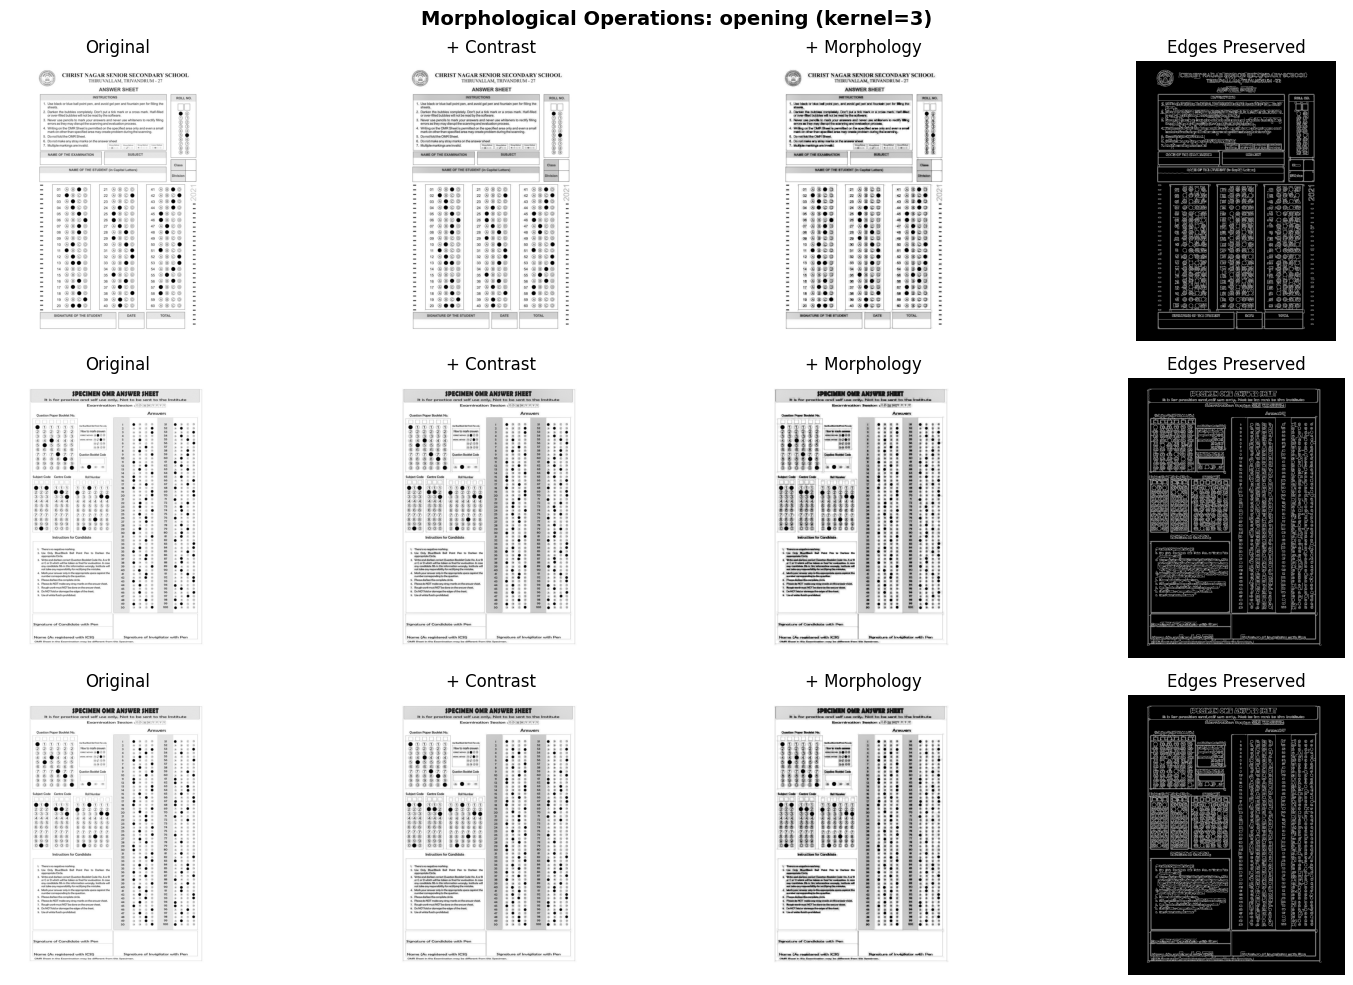

In [9]:
# Visualize best operation on 3 sample images
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle(f'Morphological Operations: {best_operation} ({best_params})', fontsize=14, fontweight='bold')

for idx in range(3):
    img_path = image_files[idx]
    original = cv2.imread(str(img_path))
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    
    # Apply contrast enhancement
    contrast_enhanced = apply_clahe(gray)
    
    # Apply best morphology
    if best_operation == 'none':
        final = contrast_enhanced
    elif best_operation == 'opening':
        kernel_size = int(best_params.split('=')[1])
        final = apply_opening(contrast_enhanced, kernel_size)
    elif best_operation == 'closing':
        kernel_size = int(best_params.split('=')[1])
        final = apply_closing(contrast_enhanced, kernel_size)
    elif best_operation == 'combined':
        params_list = best_params.split(', ')
        open_k = int(params_list[0].split('=')[1])
        close_k = int(params_list[1].split('=')[1])
        final = apply_combined_morphology(contrast_enhanced, open_k, close_k)
    
    # Calculate edge images for visualization
    edges_original = cv2.Canny(gray, 50, 150)
    edges_contrast = cv2.Canny(contrast_enhanced, 50, 150)
    edges_final = cv2.Canny(final, 50, 150)
    
    # Original
    axes[idx, 0].imshow(gray, cmap='gray')
    axes[idx, 0].set_title('Original')
    axes[idx, 0].axis('off')
    
    # Contrast Enhanced
    axes[idx, 1].imshow(contrast_enhanced, cmap='gray')
    axes[idx, 1].set_title('+ Contrast')
    axes[idx, 1].axis('off')
    
    # Final (with morphology)
    axes[idx, 2].imshow(final, cmap='gray')
    axes[idx, 2].set_title('+ Morphology')
    axes[idx, 2].axis('off')
    
    # Edge comparison
    axes[idx, 3].imshow(edges_final, cmap='gray')
    axes[idx, 3].set_title('Edges Preserved')
    axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()

## Visualization: Operation Performance Chart

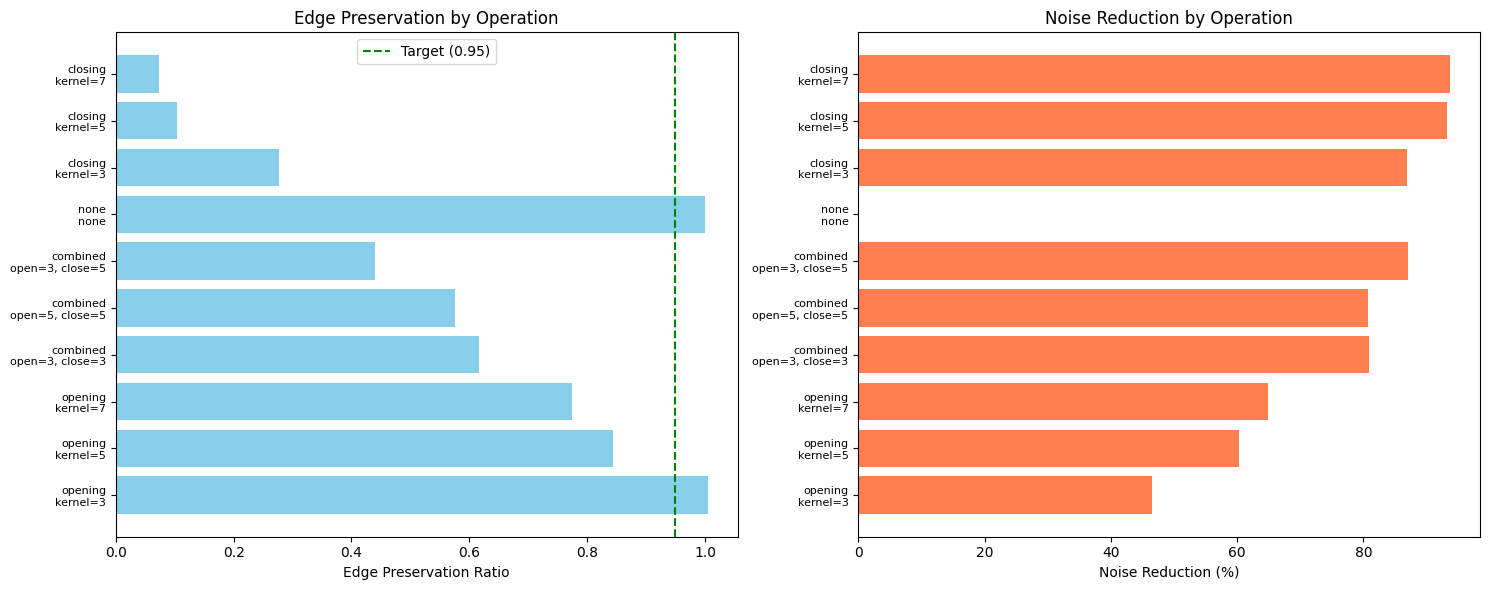

In [10]:
# Bar chart comparing operations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

summary_reset = summary.reset_index()
summary_reset['label'] = summary_reset['operation'] + '\n' + summary_reset['parameters']

# Edge Preservation
axes[0].barh(range(len(summary_reset)), summary_reset['edge_preservation'], color='skyblue')
axes[0].set_yticks(range(len(summary_reset)))
axes[0].set_yticklabels(summary_reset['label'], fontsize=8)
axes[0].set_xlabel('Edge Preservation Ratio')
axes[0].set_title('Edge Preservation by Operation')
axes[0].axvline(x=0.95, color='g', linestyle='--', label='Target (0.95)')
axes[0].legend()

# Noise Reduction
axes[1].barh(range(len(summary_reset)), summary_reset['noise_reduction_pct'], color='coral')
axes[1].set_yticks(range(len(summary_reset)))
axes[1].set_yticklabels(summary_reset['label'], fontsize=8)
axes[1].set_xlabel('Noise Reduction (%)')
axes[1].set_title('Noise Reduction by Operation')

plt.tight_layout()
plt.show()

## Results Table

In [11]:
# Print formatted results
print("\n" + "="*90)
print("DETAILED MORPHOLOGICAL OPERATIONS RESULTS")
print("="*90)
print(f"{'Operation':<15} {'Parameters':<20} {'Edge Pres.':<12} {'Noise Red.':<12} {'Visual Q.':<12}")
print("-" * 90)

for idx, row in summary.iterrows():
    operation, params = idx
    print(f"{operation:<15} {params:<20} {row['edge_preservation']:<12.3f} {row['noise_reduction_pct']:<12.1f} {row['visual_quality']:<12.3f}")

print("="*90)


DETAILED MORPHOLOGICAL OPERATIONS RESULTS
Operation       Parameters           Edge Pres.   Noise Red.   Visual Q.   
------------------------------------------------------------------------------------------
opening         kernel=3             1.005        46.4         0.789       
opening         kernel=5             0.844        60.4         0.748       
opening         kernel=7             0.775        64.8         0.724       
combined        open=3, close=3      0.616        80.9         0.693       
combined        open=5, close=5      0.576        80.7         0.668       
combined        open=3, close=5      0.440        87.0         0.612       
none            none                 1.000        0.0          0.600       
closing         kernel=3             0.277        87.0         0.514       
closing         kernel=5             0.104        93.2         0.435       
closing         kernel=7             0.074        93.8         0.419       


## Observations

**Berdasarkan hasil eksperimen:**
- Best approach: *[Will be filled after execution]*
- Edge preservation: *[maintained/improved with ratio X.XX]*
- Artifacts: *[none/minimal observations]*

## Recommendation

**Untuk Notebook 4 (Full Pipeline):**
- Use operation: *[Best operation + kernel sizes]*
- Pipeline sequence: Quality Assessment → Contrast Enhancement → Morphology
- Expected overall quality: *[prediction based on combined improvements]*

---

Success Criteria: ✅ Noise removed + edges preserved + parameters documented